# Create escape vecstor where binding =prod(1-escape ratio)

Applied on all cao et al. dataset


In [1]:
import matplotlib.pyplot as plt#5,7 best:.42, .47; pnas: 18,5
BEGIN=18
END=5
import os, sys
pgm_path = '../PGM/'

sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')
# sys.path.append('DNA_utils/')
# imports
import utilities, Proteins_utils, sequence_logo, plots_utils 

import rbm, RBM_utils

import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


e:\PATHS_NEW\covid\ab_resilience\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\PATHS_NEW\covid\ab_resilience\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
import os 
os.listdir()

['escape vectors cao.ipynb', 'exp_data']

In [3]:
df_bloom=pd.read_csv('exp_data/results/escape.csv', sep=',')
df_bloom=df_bloom[df_bloom['site']>=349] 
df_bloom=df_bloom[df_bloom['site']<=526]
#reset index

df_bloom

C:\Users\maria\AppData\Local\Temp\ipykernel_21692\2235223161.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bloom=pd.read_csv('exp_data/results/escape.csv', sep=',')


,site,wildtype,mutation,mut_escape,antibody,group,study
58,365,Y,A,0.50810,BD55-5840,D2.440,repeated_2023
59,365,Y,D,0.49170,BD55-5840,D2.440,repeated_2023
60,365,Y,F,0.10140,BD55-5840,D2.440,repeated_2023
61,365,Y,G,0.46810,BD55-5840,D2.440,repeated_2023
62,365,Y,I,0.12810,BD55-5840,D2.440,repeated_2023
...,...,...,...,...,...,...,...
577098,514,NaN,F,0.01613,XGv-422,E3,imprinted_2022
577099,514,NaN,I,0.02397,XGv-422,E3,imprinted_2022
577100,514,NaN,M,0.05784,XGv-422,E3,imprinted_2022
577101,514,NaN,R,0.02008,XGv-422,E3,imprinted_2022


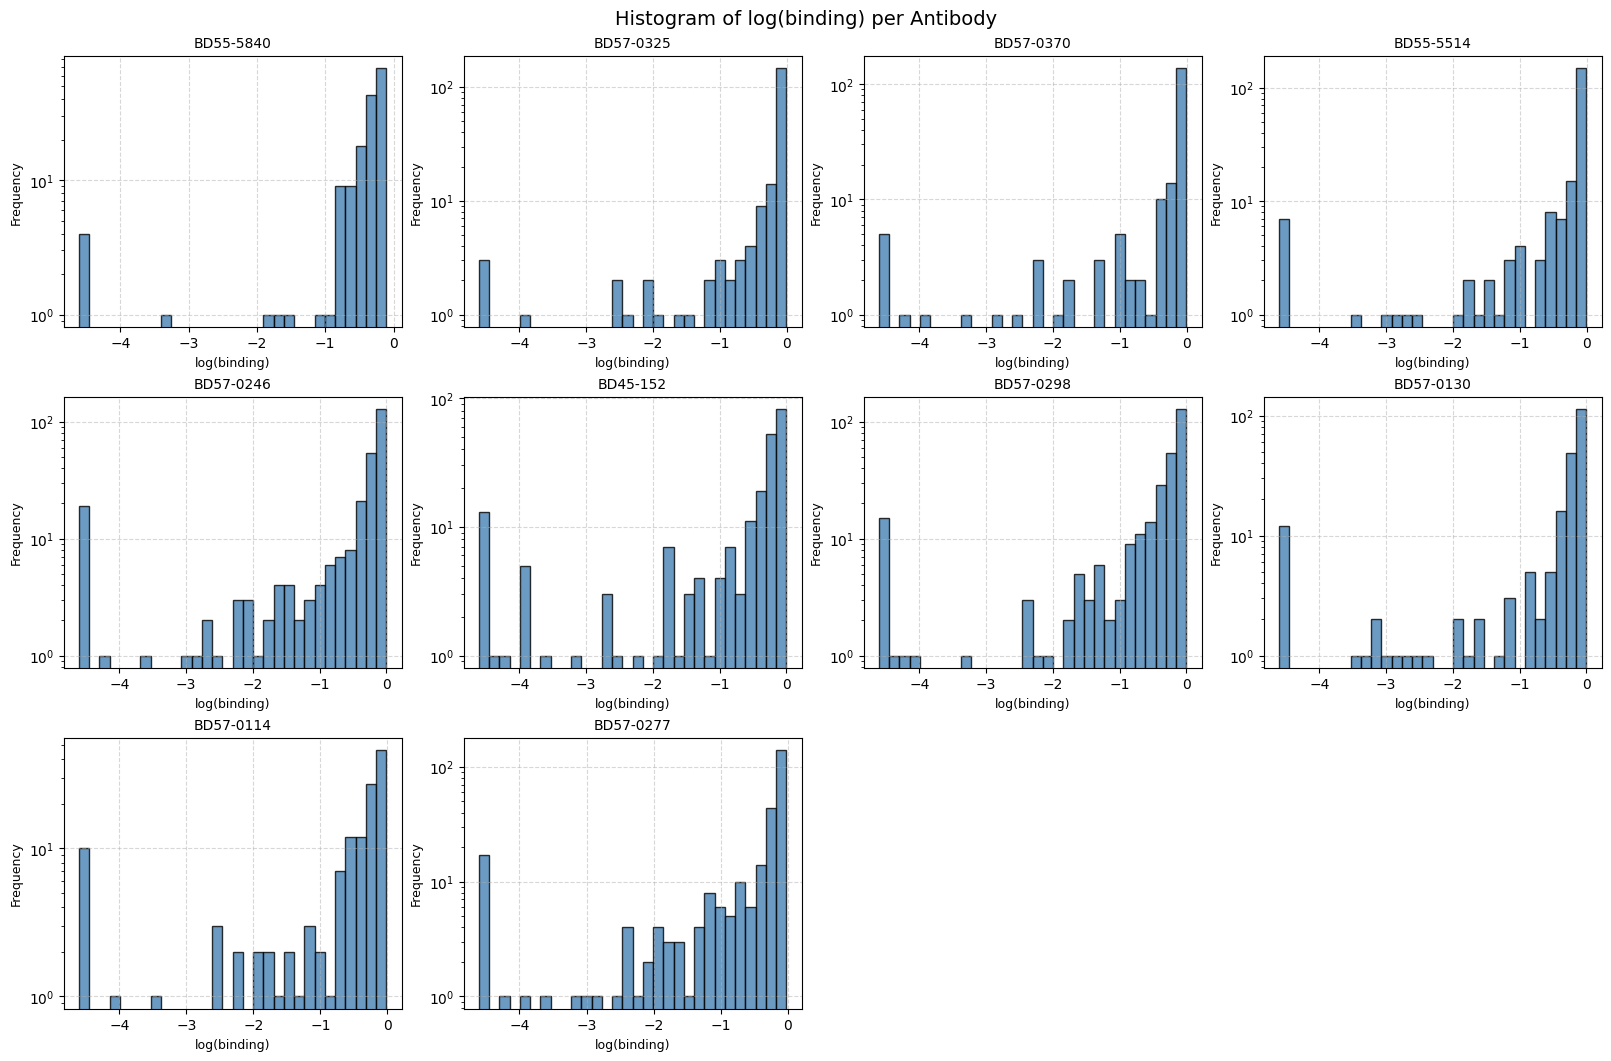

In [6]:
#put values < 0.01 to 0
df_bloom['mut_escape'] = np.where(df_bloom['mut_escape'] < 0.001, 0.001, df_bloom['mut_escape'])
#max value is 0.99
df_bloom['mut_escape'] = np.where(df_bloom['mut_escape'] > 0.99, 0.99, df_bloom['mut_escape'])
#create binding=1-mut_escape
df_bloom['binding'] = 1 - df_bloom['mut_escape']
df_bloom['log_binding'] = np.log(df_bloom['binding'])

#plot histogram of log binding for each unique antibody
# Get unique antibodies
antibodies = df_bloom['antibody'].unique()[:10]
n = len(antibodies)

# Determine subplot grid
cols = 4
rows = (n + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), constrained_layout=True)
axes = axes.flatten()

# Plot histograms
for i, ab in enumerate(antibodies):
    ax = axes[i]
    ab_data = df_bloom[df_bloom['antibody'] == ab]['log_binding']
    ax.hist(ab_data, bins=30, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_title(ab, fontsize=10)
    ax.set_xlabel('log(binding)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_yscale('log')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Histogram of log(binding) per Antibody", fontsize=14)
plt.show()


In [7]:
df_bloom.columns

Index(['site', 'wildtype', 'mutation', 'mut_escape', 'antibody', 'group',
       'study', 'binding', 'log_binding'],
      dtype='object')

# Escape vectors

In [ ]:
#df_bloom has following columns. 
#for every condition in df bloom, create an array of size (178, 20) full of zeros
# site starts at 349 and ends at 526. AMino acid encodings are  below
aa = [
    "A",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "V",
    "W",
    "Y",
    "-",
]
antibodies = df_bloom['antibody'].unique()

#add log_binding value of every row to the array at the index of the site and the amino acid
#put the array in 1D and save it
for condition in antibodies:
    # Create a 2D array of zeros with shape (178, 20)
    q = np.ones((178, 20))*np.log(1-0.001)

    # Get the data for the current condition
    condition_data = df_bloom[df_bloom['antibody'] == condition]

    # Iterate through each row in the condition data
    for index, row in condition_data.iterrows():
        site = row['site'] - 349  # Adjust for zero-based indexing
        aa_index = aa.index(row['mutation'])
        q[site, aa_index] = row['log_binding']

    #check absence of nan
    if np.isnan(q).any():
        print('nan in array')
        raise ValueError('nan in array')


    # Save the array to a file after reshaping it to 1D
    q = q.flatten()
    # Save the array to a file


    np.save('escape_vectors/'+condition+'delta_G.npy', q)
    print('escape_vectors/'+condition+'delta_G.npy')



no nan in array
escape_vectors/BD55-5840delta_G.npy
no nan in array
escape_vectors/BD57-0325delta_G.npy
no nan in array
escape_vectors/BD57-0370delta_G.npy
no nan in array
escape_vectors/BD55-5514delta_G.npy
no nan in array
escape_vectors/BD57-0246delta_G.npy
no nan in array
escape_vectors/BD45-152delta_G.npy
no nan in array
escape_vectors/BD57-0298delta_G.npy
no nan in array
escape_vectors/BD57-0130delta_G.npy
no nan in array
escape_vectors/BD57-0114delta_G.npy
no nan in array
escape_vectors/BD57-0277delta_G.npy
no nan in array
escape_vectors/BD57-0253delta_G.npy
no nan in array
escape_vectors/BD45-231delta_G.npy
no nan in array
escape_vectors/BD45-228delta_G.npy
no nan in array
escape_vectors/BD57-0347delta_G.npy
no nan in array
escape_vectors/BD57-0180delta_G.npy
no nan in array
escape_vectors/BD57-0383delta_G.npy
no nan in array
escape_vectors/BD57-0257delta_G.npy
no nan in array
escape_vectors/BD45-70delta_G.npy
no nan in array
escape_vectors/BD57-0237delta_G.npy
no nan in array
e